In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1. Configurações Iniciais de Tempo (1000 minutos)
tempo = np.arange(0, 1000, 1)

In [3]:
# 2. Criando as Métricas Fictícias (Domínio do Tempo)
# Vamos colocar um ritmo comum: um pico a cada 20 minutos (Frequência = 1/20 = 0.05 Hz)
ritmo_compartilhado = np.sin(2 * np.pi * (1/20) * tempo)

In [4]:
# A CPU terá o ritmo compartilhado + um pico rápido a cada 5 minutos + ruído
ruido_cpu = np.random.normal(0, 0.5, len(tempo))
ritmo_exclusivo_cpu = 0.5 * np.sin(2 * np.pi * (1/5) * tempo)
metrica_cpu = 50 + 10 * (ritmo_compartilhado + ritmo_exclusivo_cpu) + ruido_cpu

In [5]:
# A Memória terá apenas o ritmo compartilhado + um ruído leve
ruido_memoria = np.random.normal(0, 0.2, len(tempo))
metrica_memoria = 60 + 5 * ritmo_compartilhado + ruido_memoria

In [7]:
# 3. Aplicando a rFFT (Transformada de Fourier Real)
# O algoritmo extrai os componentes reais de frequência
frequencias_calculadas = np.fft.rfftfreq(len(tempo), d=1) # Eixo X da frequência

rfft_cpu = np.abs(np.fft.rfft(metrica_cpu - np.mean(metrica_cpu))) # Removemos a média para ignorar o "chão" do gráfico
rfft_memoria = np.abs(np.fft.rfft(metrica_memoria - np.mean(metrica_memoria)))

In [8]:
# 4. Plotando os Gráficos para Comparação
plt.figure(figsize=(14, 10))

<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

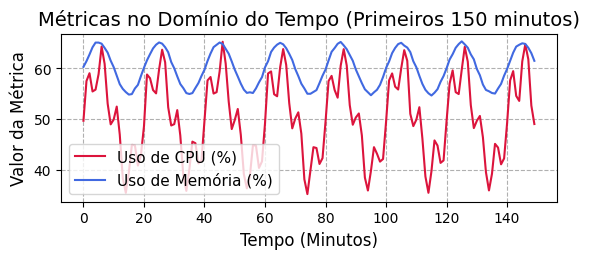

In [9]:
# Subplot 1: Gráfico no Domínio do Tempo (O que o Engenheiro de TI vê)
plt.subplot(2, 1, 1)
plt.plot(tempo[:150], metrica_cpu[:150], label='Uso de CPU (%)', color='crimson')
plt.plot(tempo[:150], metrica_memoria[:150], label='Uso de Memória (%)', color='royalblue')
plt.title('Métricas no Domínio do Tempo (Primeiros 150 minutos)', fontsize=14)
plt.xlabel('Tempo (Minutos)', fontsize=12)
plt.ylabel('Valor da Métrica', fontsize=12)
plt.grid(True, linestyle='--')
plt.legend(fontsize=11)

(0.0, 0.3)

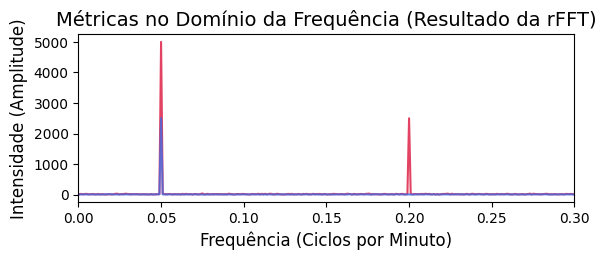

In [10]:
# Subplot 2: Gráfico no Domínio da Frequência (O que o FuseGuard vê)
plt.subplot(2, 1, 2)
# Vamos limitar o eixo X para facilitar a visualização das frequências baixas (ritmos principais)
plt.plot(frequencias_calculadas, rfft_cpu, label='Ritmos da CPU', color='crimson', alpha=0.8)
plt.plot(frequencias_calculadas, rfft_memoria, label='Ritmos da Memória', color='royalblue', alpha=0.8)
plt.title('Métricas no Domínio da Frequência (Resultado da rFFT)', fontsize=14)
plt.xlabel('Frequência (Ciclos por Minuto)', fontsize=12)
plt.ylabel('Intensidade (Amplitude)', fontsize=12)
plt.xlim(0, 0.3) # Foco nas frequências que importam

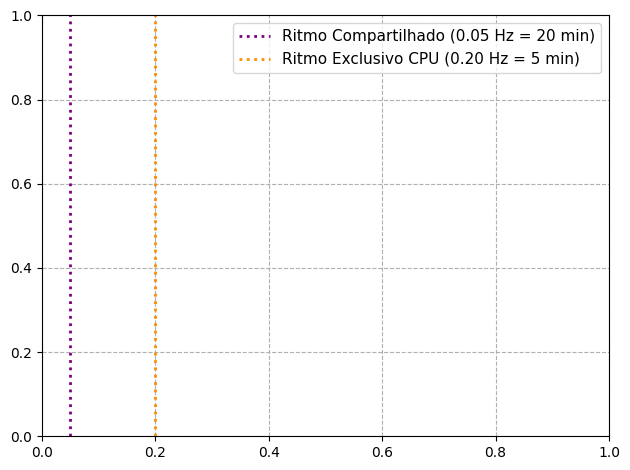

In [11]:
# Destacando o ritmo compartilhado encontrado pela rFFT (1 ciclo a cada 20 min = 0.05)
plt.axvline(x=0.05, color='purple', linestyle=':', linewidth=2, label='Ritmo Compartilhado (0.05 Hz = 20 min)')
# Destacando o ritmo exclusivo da CPU (1 ciclo a cada 5 min = 0.20)
plt.axvline(x=0.20, color='darkorange', linestyle=':', linewidth=2, label='Ritmo Exclusivo CPU (0.20 Hz = 5 min)')
plt.grid(True, linestyle='--')
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()